In [9]:
import pandas as pd
from pathlib import Path
# Define base folder
base = Path("../Data/Raw Data")
# Build paths
nairobi_path = base / "openaq_location_Nairobi_6237507_measurments.csv"
# Load Nairobi dataset
nairobi_df = pd.read_csv(nairobi_path)

# Inspect first few rows
print(nairobi_df.head())
print(nairobi_df.columns)



   location_id        location_name parameter  value   unit  \
0      6237507  Providence Academy        pm1    3.8  µg/m³   
1      6237507  Providence Academy        pm1    2.0  µg/m³   
2      6237507  Providence Academy        pm1    1.1  µg/m³   
3      6237507  Providence Academy        pm1    0.0  µg/m³   
4      6237507  Providence Academy        pm1    1.3  µg/m³   

            datetimeUtc              datetimeLocal        timezone  latitude  \
0  2026-04-22T01:00:00Z  2026-04-22T04:00:00+03:00  Africa/Nairobi -1.230255   
1  2026-04-22T02:00:00Z  2026-04-22T05:00:00+03:00  Africa/Nairobi -1.230255   
2  2026-04-22T03:00:00Z  2026-04-22T06:00:00+03:00  Africa/Nairobi -1.230255   
3  2026-04-22T04:00:00Z  2026-04-22T07:00:00+03:00  Africa/Nairobi -1.230255   
4  2026-04-22T05:00:00Z  2026-04-22T08:00:00+03:00  Africa/Nairobi -1.230255   

   longitude  country_iso  isMobile  isMonitor   owner_name     provider  
0  36.881388          NaN       NaN        NaN  AirGradient  AirG

In [10]:
#Data Cleaning
#Keeping only essential columns

nairobi_df = nairobi_df[['parameter','value','unit','datetimeLocal','latitude','longitude']]

# Convert datetimeLocal to datetime type
nairobi_df['datetimeLocal'] = pd.to_datetime(nairobi_df['datetimeLocal'])

print(nairobi_df.head())


  parameter  value   unit             datetimeLocal  latitude  longitude
0       pm1    3.8  µg/m³ 2026-04-22 04:00:00+03:00 -1.230255  36.881388
1       pm1    2.0  µg/m³ 2026-04-22 05:00:00+03:00 -1.230255  36.881388
2       pm1    1.1  µg/m³ 2026-04-22 06:00:00+03:00 -1.230255  36.881388
3       pm1    0.0  µg/m³ 2026-04-22 07:00:00+03:00 -1.230255  36.881388
4       pm1    1.3  µg/m³ 2026-04-22 08:00:00+03:00 -1.230255  36.881388


## Time Series Analysis

In this section, I visualize how key environmental parameters change over time.  
Specifically, I plot **PM2.5 concentrations**, **temperature**, and **relative humidity** across the 24‑hour period recorded at Providence Academy.  
These time series plots help reveal daily patterns, highlight peaks (such as pollution spikes), and show how weather conditions like temperature and humidity fluctuate throughout the day.  
By examining these trends side by side, I can better understand the relationship between air quality and local meteorological conditions.



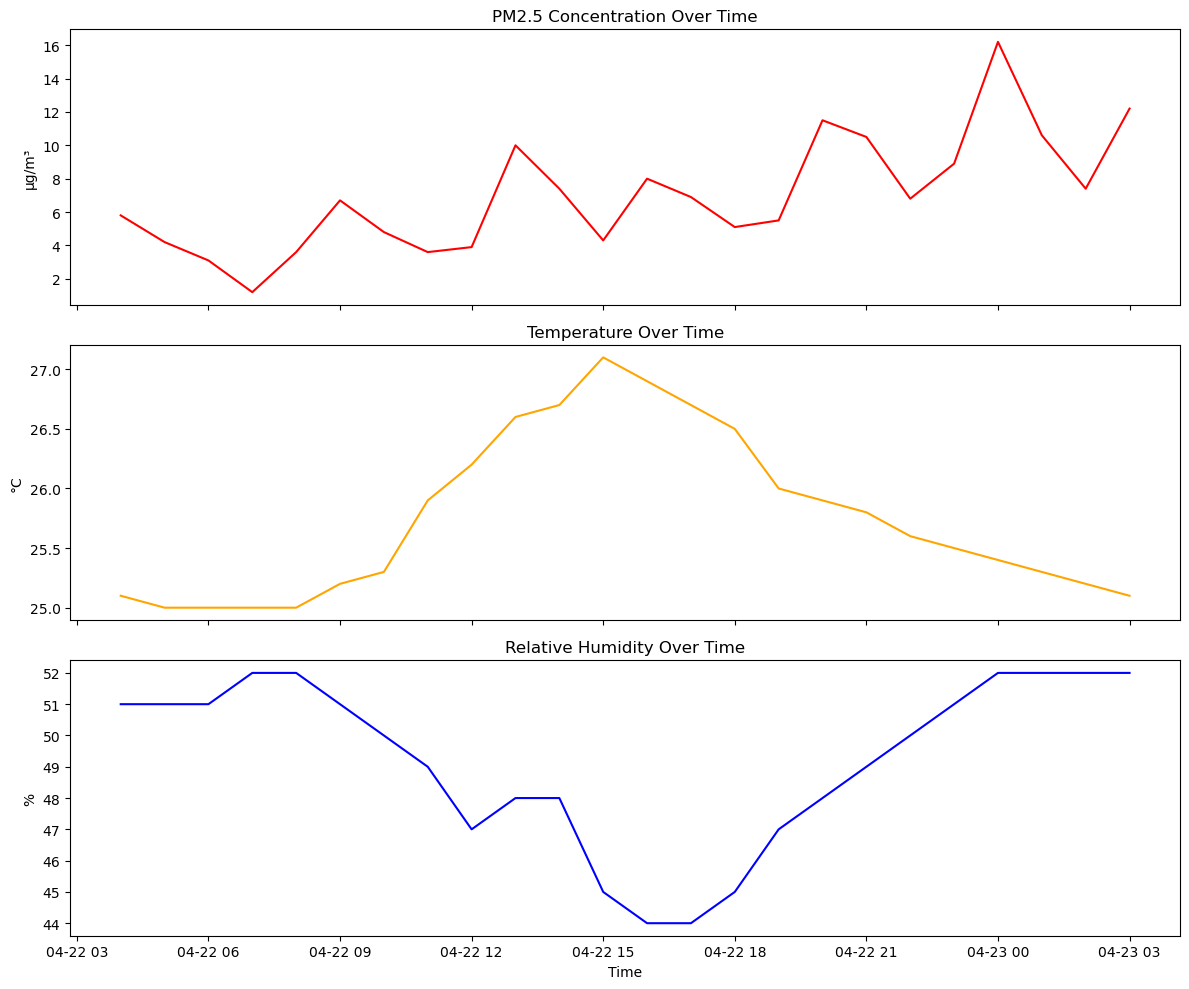

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter each parameter
pm25 = nairobi_df[nairobi_df['parameter'] == 'pm25']
temp = nairobi_df[nairobi_df['parameter'] == 'temperature']
rh = nairobi_df[nairobi_df['parameter'] == 'relativehumidity']

# Plot
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax[0].plot(pm25['datetimeLocal'], pm25['value'], color='red')
ax[0].set_title("PM2.5 Concentration Over Time")
ax[0].set_ylabel("µg/m³")

ax[1].plot(temp['datetimeLocal'], temp['value'], color='orange')
ax[1].set_title("Temperature Over Time")
ax[1].set_ylabel("°C")

ax[2].plot(rh['datetimeLocal'], rh['value'], color='blue')
ax[2].set_title("Relative Humidity Over Time")
ax[2].set_ylabel("%")

plt.xlabel("Time")
plt.tight_layout()
# Save the figure
plt.savefig("time_series_plots.png", dpi=300)
plt.show()


### Observed Trends in Time Series

The time series plots reveal distinct daily patterns in air quality and weather conditions:

- **PM2.5 Concentration**: Levels remain relatively low during the early morning hours but rise sharply in the evening, peaking around 21:00 at 16.2 µg/m³. This suggests possible human activity or environmental factors contributing to evening pollution spikes.  
- **Temperature**: The temperature shows a gradual increase through the morning, reaching a peak near midday (around 27°C), before slowly declining into the evening. This reflects a typical diurnal cycle.  
- **Relative Humidity**: Humidity decreases steadily from early morning (about 52%) to mid-afternoon (around 44%), then rises again in the evening. This inverse relationship with temperature is consistent with expected meteorological behavior.

Together, these plots highlight how **air quality dynamics (PM2.5)** interact with **weather conditions (temperature and humidity)** over the course of a day, providing valuable context for environmental health analysis.

### Conclusion

The combined trends show that **air quality at Providence Academy is strongly influenced by daily meteorological cycles**.  
PM2.5 concentrations rise sharply in the evening, while temperature follows a typical daytime peak and humidity moves inversely.  
This suggests that pollution events are not random but occur alongside predictable weather shifts, highlighting the importance of monitoring both air quality and local climate conditions together.



## Correlation Heatmap

In this section, I explore the relationships between different environmental parameters measured at Providence Academy.  
By pivoting the dataset so that each parameter becomes a column, I can compute pairwise correlations and visualize them in a heatmap.  
This helps reveal how variables such as **PM2.5**, **PM1**, **temperature**, **relative humidity**, and **particle count (um003)** interact with one another.  
For example, particulate matter values are expected to correlate strongly, while temperature and humidity often show an inverse relationship.  
The heatmap provides a quick overview of these connections, guiding deeper interpretation of air quality dynamics.


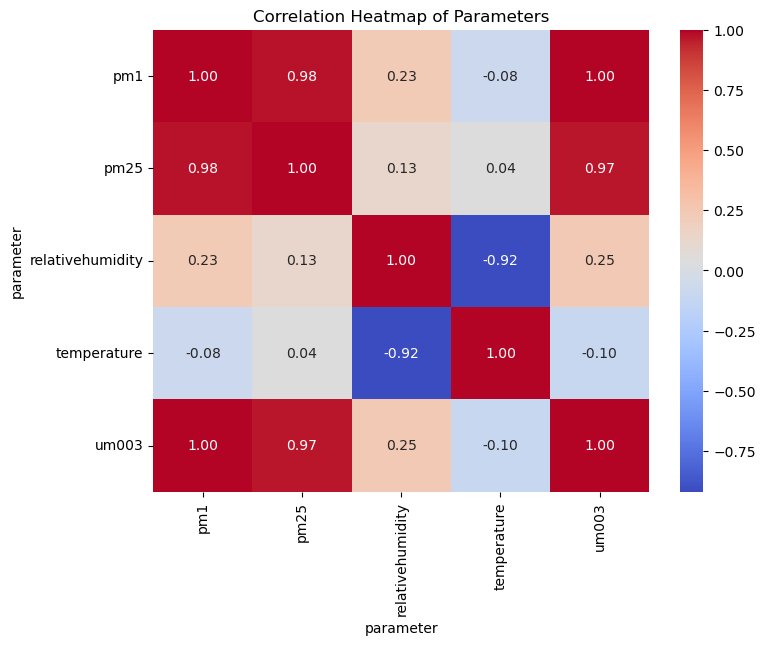

In [12]:
# Pivot data: datetime as index, parameters as columns
pivot_df = nairobi_df.pivot(index='datetimeLocal', columns='parameter', values='value')

# Correlation matrix
corr = pivot_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Parameters")
# Save the heatmap
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


### Findings from the Correlation Heatmap

The correlation analysis highlights several important relationships among the measured parameters:

- **Strong Positive Correlations**:  
  - PM1, PM2.5, and particle count (um003) are almost perfectly correlated (values above 0.97).  
    This indicates that these particulate matter metrics move together, reflecting consistency in air quality measurements.  

- **Temperature vs Relative Humidity**:  
  - A strong negative correlation (-0.92) shows that as temperature rises, relative humidity falls.  
    This is a typical meteorological pattern and confirms the inverse relationship between heat and moisture in the air.  

- **Weak or Minimal Correlations**:  
  - PM values show only weak correlations with temperature and humidity, suggesting that particulate pollution levels are not directly driven by short-term weather changes in this dataset.  

Overall, the heatmap reveals that **particulate matter metrics are tightly linked**, while **temperature and humidity are strongly inversely related**, offering insight into both pollution dynamics and local climate behavior.



## Air Quality Assessment

In this section, I evaluate the measured PM2.5 concentrations against the World Health Organization (WHO) guidelines. The WHO recommends that the **24‑hour mean PM2.5 concentration should not exceed 15 µg/m³** to protect public health. By calculating the daily average from the dataset and identifying hours where PM2.5 levels rise above this threshold, I can assess whether the air quality at Providence Academy remains within safe limits or shows signs of potential health risk. This analysis provides a practical interpretation of the data, moving beyond trends and correlations to real-world implications for environmental health.


In [13]:
pm25_mean = pm25['value'].mean()
print(f"Daily mean PM2.5: {pm25_mean:.2f} µg/m³")

if pm25_mean > 15:
    print("⚠️ Exceeds WHO guideline for daily exposure.")
else:
    print("✅ Within WHO guideline for daily exposure.")


Daily mean PM2.5: 7.01 µg/m³
✅ Within WHO guideline for daily exposure.


### Air Quality Assessment Results

The calculated **daily mean PM2.5 concentration was 7.01 µg/m³**, which is well below the WHO guideline of 15 µg/m³ for 24‑hour exposure.  
This indicates that the air quality at Providence Academy during the measured period was **within safe limits**, posing no significant health risk from fine particulate matter.  
While short-term spikes were observed in the evening hours, the overall daily average remained compliant with international standards.
